In [ ]:
import time

import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter

import encosid

In [2]:
MOTOR_IF = "can0"
MOTOR_ID = 3
BRAKE_ID = 4

SIGNAL_DT_MS = 1
MOTOR_KT = 4.2

## Измерение отклика

Управление по USB-CAN

In [7]:
# Устрание разрывов позиции (перескок на 2pi)
def stitch(Y, gap=2*np.pi, tol=1e-2):
  Y = Y.copy()
  for i in range(len(Y) - 1):
    dy = Y[i + 1] - Y[i]
    shift = dy
    if np.abs(dy) >= gap - tol:
      Y[i + 1:] -= shift
  return Y

# Пример процедуры измерения
def measure_responce(ctrl, dt):
  gen = encosid.SignalGenerator(MOTOR_IF, MOTOR_ID)

  gen.set_mode(gen.mode.torque, 0)
  # gen.set_mode(gen.mode.position, kp) # kp < 500
  # gen.set_mode(gen.mode.velocity, kd) # kd < 5

  pos, vel, cur = map(np.array, gen.play_signal(ctrl, dt))

  pos = stitch(pos - pos[0])
  vel = savgol_filter(vel, 101, 3)
  trq = MOTOR_KT * savgol_filter(cur, 101, 3)

  return pos, vel, trq

/tmp/ipykernel_9082/1750855993.py:20: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axis.legend()


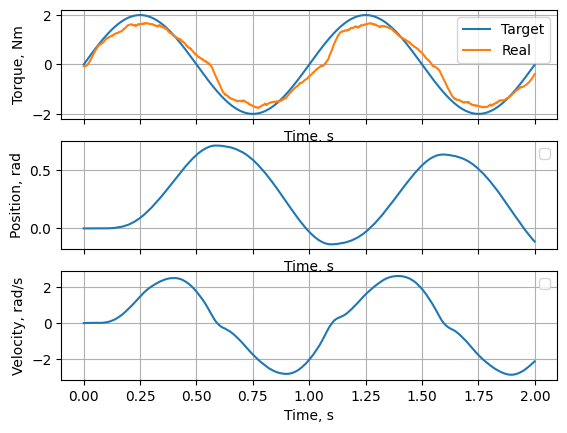

In [ ]:
T = np.arange(0, 2, 1e-3 * SIGNAL_DT_MS)
ctrl = 2 * np.sin(2 * np.pi * T)
pos, vel, trq = measure_responce(ctrl, SIGNAL_DT_MS)

fig, ax = plt.subplots(3, 1, sharex = True)

ax[0].set_ylabel("Torque, Nm")
ax[0].plot(T, ctrl, label="Target")
ax[0].plot(T, trq, label="Real")

ax[1].set_ylabel("Position, rad")
ax[1].plot(T, pos)

ax[2].set_ylabel("Velocity, rad/s")
ax[2].plot(T, vel)

for axis in ax:d
    axis.set_xlabel("Time, s")
    axis.grid()
    axis.legend()

plt.show()

## Режим электротормоза

Управление по USB-CAN

In [14]:
gen = encosid.SignalGenerator(MOTOR_IF, MOTOR_ID)

kp = 10
kd = 1

# Удерживает текущую позицию
gen.brake(kp, kd) 
time.sleep(5)
gen.release()

## Измерение на стенде

Используются два мотора. Электротормоз управляется через `encosid.SignalGenerator.brake`. Исследуемый мотор управляется внешним контроллером через модуль `pyonb`. Оттуда же приходят измерения с тензодатчиков.

Подается целевой момент в виде chirp-сигнала. Возвращаются целевой момент, момент на тензодатчике, ток.

In [ ]:
import pyonb
from PyQt5.QtCore import QVariant, QByteArray, QDataStream, QIODevice

In [3]:
def tenso_experiment(freq_start, freq_end, duration, amplitude, brake_kp):
  brake = encosid.SignalGenerator(MOTOR_IF, BRAKE_ID)
  onb = pyonb.Client()

  # Fetch devices
  onb.fetch_device("drive")
  onb.fetch_device("Analyzer")
  onb.fetch_device("SigGen")

  onb.set_param_bool("drive", "enable", True)

  onb.set_param_float("Analyzer", "freqStart", freq_start)
  onb.set_param_float("Analyzer", "freqEnd",   freq_end)
  onb.set_param_float("Analyzer", "duration",  duration)

  onb.invoke_str("Analyzer", "set input", "torque")
  onb.set_param_float("Analyzer", "targetAmplitude", amplitude)

  # Measuring process
  onb.set_ag_request("drive", 5, ["speed", "tensoFiltered", "torque", "targetTorque"])

  brake.brake(brake_kp, 0)
  onb.invoke_str("Analyzer", "start/stop")
  time.sleep(duration)
  brake.release()

  onb.set_ag_request("drive", 0, []) # disable
  samples = onb.get_samples()

  data = []
  for sample in samples:
    b = bytearray(map(ord, sample))

    arr = QByteArray(b)
    ds = QDataStream(arr, QIODevice.ReadOnly)

    v = QVariant()
    ds >> v

    data.append(v.value())
  
  def extract_key(data, key):
    d = []
    for sample in data:
      if key in sample:
        d.append(sample[key])
    
    return np.array(d)

  current = extract_key(data, 'torque')
  tenso_torque  = extract_key(data, 'tensoFiltered')
  target_torque = extract_key(data, 'targetTorque')

  return target_torque, tenso_torque, current

/tmp/ipykernel_9527/1909996852.py:25: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axis.legend()


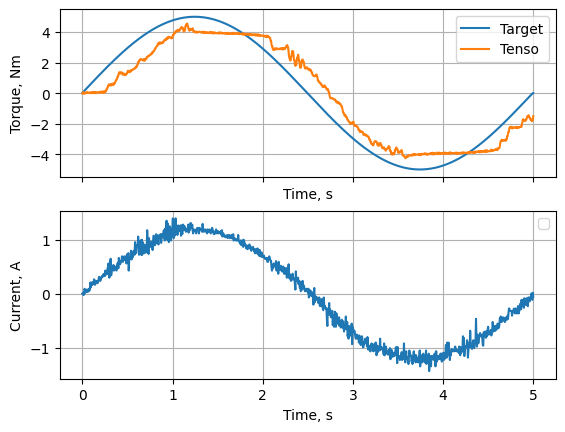

In [5]:
duration = 5

target_torque, tenso_torque, current = tenso_experiment(
    freq_start=(1 / duration),
    freq_end=(1 / duration),
    duration=duration,
    amplitude=5,
    brake_kp=5
)

T = np.linspace(0, duration, len(target_torque))

fig, ax = plt.subplots(2, 1, sharex = True)

ax[0].set_ylabel("Torque, Nm")
ax[0].plot(T, target_torque, label="Target")
ax[0].plot(T, tenso_torque, label="Tenso")

ax[1].set_ylabel("Current, A")
ax[1].plot(T, current)

for axis in ax:
    axis.set_xlabel("Time, s")
    axis.grid()
    axis.legend()

plt.show()